In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib



In [5]:
# 1. Load the dataset
df = pd.read_csv('Downloads/iplcric/all_season_summary.csv')


In [7]:
# 2. Explore the dataset
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())


Dataset shape: (1032, 45)

First 5 rows:
   season       id                                          name  short_name  \
0  2023.0  1359475          Gujarat Titans v Chennai Super Kings    GT v CSK   
1  2023.0  1359476          Punjab Kings v Kolkata Knight Riders  PBKS v KKR   
2  2023.0  1359477         Lucknow Super Giants v Delhi Capitals    LSG v DC   
3  2023.0  1359478        Sunrisers Hyderabad v Rajasthan Royals    SRH v RR   
4  2023.0  1359479  Royal Challengers Bangalore v Mumbai Indians    RCB v MI   

                                         description home_team away_team  \
0  1st Match (N), Indian Premier League at Ahmeda...        GT       CSK   
1  2nd Match (D/N), Indian Premier League at Chan...      PBKS       KKR   
2  3rd Match (N), Indian Premier League at Luckno...       LSG        DC   
3  4th Match (D/N), Indian Premier League at Hyde...       SRH        RR   
4  5th Match (N), Indian Premier League at Bengal...       RCB        MI   

  toss_won    decisio

In [11]:
# 3. Data preprocessing
# Replace team names (KXIP to PBKS)
# team_mapping = {'KXIP': 'PBKS','Delhi Daredevils': 'Delhi Capitals',
#     'Kings XI Punjab': 'Punjab Kings',
#     'Rising Pune Supergiant': 'RPS',
#     'Deccan Chargers': 'SRH',
#     'Gujarat Lions': 'GL',
#     'Pune Warriors': 'PWI',
#     'Kochi Tuskers Kerala': 'Kochi',
#                'Mumbai Indians: MI', 'Chennai Super Kings': 'CSK', }

team_mapping = {
    'Deccan Chargers': 'SRH',  # replaced by Sunrisers Hyderabad
    'Sunrisers Hyderabad': 'SRH',
    
    'Delhi Daredevils': 'DC',  # rebranded to Delhi Capitals
    'Delhi Capitals': 'DC',
    
    'Kings XI Punjab': 'PBKS',  # rebranded to Punjab Kings
    'Punjab Kings': 'PBKS',
    'KXIP': 'PBKS',
    
    'Rising Pune Supergiant': 'RPS',
    'Rising Pune Supergiants': 'RPS',
    
    'Pune Warriors': 'PWI',
    'Pune Warriors India': 'PWI',
    
    'Gujarat Lions': 'GL',
    
    'Kochi Tuskers Kerala': 'Kochi',
    
    'Chennai Super Kings': 'CSK',
    'Mumbai Indians': 'MI',
    'Royal Challengers Bangalore': 'RCB',
    'Rajasthan Royals': 'RR',
    'Kolkata Knight Riders': 'KKR',
    'Lucknow Super Giants': 'LSG',
    'Gujarat Titans': 'GT'
}


# Apply mapping to all relevant columns (home_team, away_team, winner)
for col in ['home_team', 'away_team', 'winner']:
    if col in df.columns:
        df[col] = df[col].replace(team_mapping)

print("\nAfter team name mapping:")
print(df['home_team'].unique())
print(df['away_team'].unique())
print(df['winner'].unique())



After team name mapping:
['GT' 'PBKS' 'LSG' 'SRH' 'RCB' 'CSK' 'DC' 'RR' 'KKR' 'MI' 'RPS' 'GL' 'PWI'
 'Kochi']
['CSK' 'KKR' 'DC' 'RR' 'MI' 'LSG' 'GT' 'PBKS' 'RCB' 'SRH' 'RPS' 'GL' 'PWI'
 'Kochi']
['GT' 'PBKS' 'LSG' 'RR' 'RCB' 'CSK' 'KKR' 'SRH' 'MI' 'DC' 'RPS' 'GL' nan
 'PWI' 'Kochi']


In [15]:
# 4. Feature Engineering
# Extract features that might affect match outcome
# Handle missing values if any
df = df.dropna(subset=['winner'])  # Drop rows where winner is unknown

# Create a new feature 'toss_winner_is_match_winner'
if 'toss_winner' in df.columns and 'winner' in df.columns:
    df['toss_winner_is_match_winner'] = (df['toss_won'] == df['winner']).astype(int)

# Create a new feature 'is_home_team_winner'
if 'home_team' in df.columns and 'winner' in df.columns and 'venue' in df.columns:
    # This is a simplistic approach - in a real scenario, you'd need data mapping venues to home teams
    df['is_home_team_winner'] = (df['home_team'] == df['winner']).astype(int)

# Label encode categorical features
categorical_cols = ['home_team', 'away_team', 'venue', 'toss_won', 'toss_decision']
label_encoders = {}

for col in categorical_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[f'{col}_encoded'] = le.fit_transform(df[col])
        label_encoders[col] = le

# Target variable
if 'winner' in df.columns:
    # Create binary target: 1 if team1 wins, 0 if team2 wins
    df['home_team_won'] = (df['home_team'] == df['winner']).astype(int)


In [19]:
# 5. Feature Selection
# Select relevant features for the model
feature_cols = [col for col in df.columns if '_encoded' in col]
if 'toss_winner_is_match_winner' in df.columns:
    feature_cols.append('toss_winner_is_match_winner')
if 'is_home_team_winner' in df.columns:
    feature_cols.append('is_home_team_winner')

In [21]:
# 6. Model Building
# Split the data
X = df[feature_cols]
y = df['home_team']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)


Model Accuracy: 0.9469

Classification Report:
              precision    recall  f1-score   support

         CSK       1.00      1.00      1.00        21
          DC       1.00      1.00      1.00        19
          GL       1.00      1.00      1.00         1
          GT       0.50      1.00      0.67         1
         KKR       0.84      0.95      0.89        22
       Kochi       0.00      0.00      0.00         3
         LSG       1.00      0.20      0.33         5
          MI       0.90      1.00      0.95        27
        PBKS       1.00      1.00      1.00        23
         PWI       1.00      1.00      1.00         5
         RCB       0.97      1.00      0.98        30
         RPS       1.00      0.25      0.40         4
          RR       0.91      1.00      0.95        20
         SRH       1.00      1.00      1.00        26

    accuracy                           0.95       207
   macro avg       0.87      0.81      0.80       207
weighted avg       0.94      0.9

C:\Users\vishakh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vishakh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vishakh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


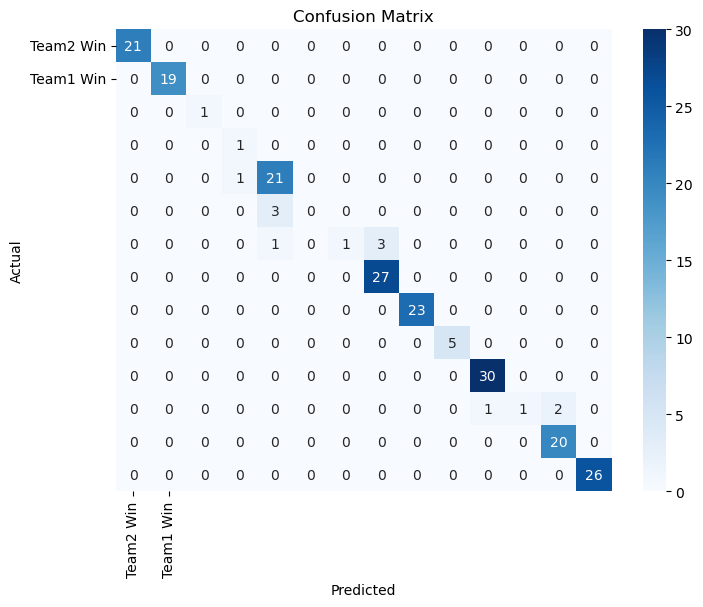


Feature Importance:
             Feature  Importance
0  home_team_encoded    0.728446
2   toss_won_encoded    0.207702
1  away_team_encoded    0.063853


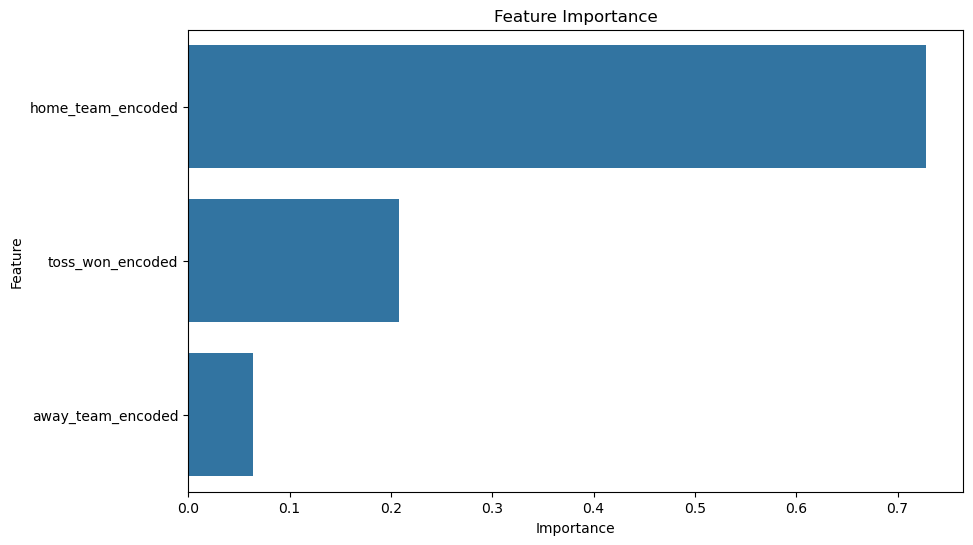

In [23]:
# 7. Model Evaluation
# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Team2 Win', 'Team1 Win'], 
            yticklabels=['Team2 Win', 'Team1 Win'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Feature Importance
feature_importance = pd.DataFrame(
    {'Feature': feature_cols, 'Importance': model.feature_importances_}
).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance')
plt.show()


In [25]:
# 8. Save the model
joblib.dump(model, 'ipl_win_predictor_model.joblib')

['ipl_win_predictor_model.joblib']

In [29]:
# 9. Function to predict win probabilities for new matches
def predict_win_probability(home_team, away_team, venue, toss_winner, toss_decision):
    # Create a dataframe for the new match
    new_match = pd.DataFrame({
        'team1': [home_team],
        'team2': [away_team],
        'venue': [venue],
        'toss_winner': [toss_winner],
        'toss_decision': [toss_decision]
    })
    
    # Replace team names if needed
    new_match = new_match.replace(team_mapping)
    
    # Encode categorical features
    for col in categorical_cols:
        if col in new_match.columns and col in label_encoders:
            le = label_encoders[col]
            # Handle new categories that weren't in the training data
            new_match[f'{col}_encoded'] = new_match[col].apply(
                lambda x: le.transform([x])[0] if x in le.classes_ else -1
            )
    
    # Add derived features
    new_match['toss_winner_is_match_winner'] = (new_match['toss_winner'] == home_team).astype(int)
    new_match['is_home_team_winner'] = 1  # Placeholder, will be updated with prediction
    
    # Select features for prediction
    X_new = new_match[feature_cols]
    
    # Predict probability
    win_prob = model.predict_proba(X_new)[0][1]  # Probability of team1 (home team) winning
    
    return {
        'home_team': home_team,
        'away_team': away_team,
        'home_team_win_probability': win_prob,
        'away_team_win_probability': 1 - win_prob
    }

# Example usage of the prediction function
match_prediction = predict_win_probability(
    home_team='MI',
    away_team='CSK',
    venue='Wankhede Stadium',
    toss_winner='MI',
    toss_decision='bat'
)

print("\nMatch Prediction Example:")
print(f"Home Team: {match_prediction['home_team']}")
print(f"Away Team: {match_prediction['away_team']}")
print(f"{match_prediction['home_team']} win probability: {match_prediction['home_team_win_probability']:.2%}")
print(f"{match_prediction['away_team']} win probability: {match_prediction['away_team_win_probability']:.2%}")

KeyError: "None of [Index(['home_team_encoded', 'away_team_encoded', 'toss_won_encoded'], dtype='object')] are in the [columns]"

In [31]:
# 9. Function to predict win probabilities for new matches
def predict_win_probability(home_team, away_team, venue, toss_winner, toss_decision):
    # Create a dataframe for the new match
    new_match = pd.DataFrame({
        'team1': [home_team],
        'team2': [away_team],
        'venue': [venue],
        'toss_winner': [toss_winner],
        'toss_decision': [toss_decision]
    })
    
    # Replace team names if needed
    new_match = new_match.replace(team_mapping)
    
    # Encode categorical features
    for col in categorical_cols:
        if col in new_match.columns and col in label_encoders:
            le = label_encoders[col]
            # Handle new categories that weren't in the training data
            new_match[f'{col}_encoded'] = new_match[col].apply(
                lambda x: le.transform([x])[0] if x in le.classes_ else -1
            )
    
    # Add derived features
    new_match['toss_winner_is_match_winner'] = (new_match['toss_winner'] == home_team).astype(int)
    new_match['is_home_team_winner'] = 1  # Placeholder, will be updated with prediction

    print("Available columns in new_match:", new_match.columns)
    print("Expected feature columns:", feature_cols)

    # Select features for prediction
    X_new = new_match[feature_cols]
    
    # Predict probability
    win_prob = model.predict_proba(X_new)[0][1]  # Probability of team1 (home team) winning
    
    return {
        'home_team': home_team,
        'away_team': away_team,
        'home_team_win_probability': win_prob,
        'away_team_win_probability': 1 - win_prob
    }

# Example usage of the prediction function
match_prediction = predict_win_probability(
    home_team='MI',
    away_team='CSK',
    venue='Wankhede Stadium',
    toss_winner='MI',
    toss_decision='bat'
)

print("\nMatch Prediction Example:")
print(f"Home Team: {match_prediction['home_team']}")
print(f"Away Team: {match_prediction['away_team']}")
print(f"{match_prediction['home_team']} win probability: {match_prediction['home_team_win_probability']:.2%}")
print(f"{match_prediction['away_team']} win probability: {match_prediction['away_team_win_probability']:.2%}")

Available columns in new_match: Index(['team1', 'team2', 'venue', 'toss_winner', 'toss_decision',
       'toss_winner_is_match_winner', 'is_home_team_winner'],
      dtype='object')
Expected feature columns: ['home_team_encoded', 'away_team_encoded', 'toss_won_encoded']


KeyError: "None of [Index(['home_team_encoded', 'away_team_encoded', 'toss_won_encoded'], dtype='object')] are in the [columns]"

In [33]:


# Example required global variables (you should have them already defined in your code)
# model - your trained ML model
# label_encoders - dictionary of LabelEncoders for categorical features
# team_mapping - team name replacements if applicable

# Define the feature columns used during model training
feature_cols = [
    'team1_encoded', 
    'team2_encoded', 
    'venue_encoded', 
    'toss_winner_encoded', 
    'toss_decision_encoded', 
    'toss_winner_is_match_winner'
]

# Categorical columns used in encoding
categorical_cols = ['team1', 'team2', 'venue', 'toss_winner', 'toss_decision']

# Function to predict win probabilities for new matches
def predict_win_probability(home_team, away_team, venue, toss_winner, toss_decision):
    # Create a dataframe for the new match
    new_match = pd.DataFrame({
        'team1': [home_team],
        'team2': [away_team],
        'venue': [venue],
        'toss_winner': [toss_winner],
        'toss_decision': [toss_decision]
    })

    # Replace team names if needed
    new_match = new_match.replace(team_mapping)

    # Encode categorical features
    for col in categorical_cols:
        if col in new_match.columns and col in label_encoders:
            le = label_encoders[col]
            new_match[f'{col}_encoded'] = new_match[col].apply(
                lambda x: le.transform([x])[0] if x in le.classes_ else -1
            )
        else:
            # Fallback if no encoder is found
            new_match[f'{col}_encoded'] = -1

    # Add derived features
    new_match['toss_winner_is_match_winner'] = (new_match['toss_winner'] == home_team).astype(int)

    # Debug print (can be removed in production)
    print("Available columns in new_match:", new_match.columns)
    print("Expected feature columns:", feature_cols)

    # Select features for prediction
    X_new = new_match[feature_cols]

    # Predict probability
    win_prob = model.predict_proba(X_new)[0][1]  # Probability of team1 (home team) winning

    return {
        'home_team': home_team,
        'away_team': away_team,
        'home_team_win_probability': win_prob,
        'away_team_win_probability': 1 - win_prob
    }

# Example usage of the prediction function
match_prediction = predict_win_probability(
    home_team='MI',
    away_team='CSK',
    venue='Wankhede Stadium',
    toss_winner='MI',
    toss_decision='bat'
)

print("\nMatch Prediction Example:")
print(f"Home Team: {match_prediction['home_team']}")
print(f"Away Team: {match_prediction['away_team']}")
print(f"{match_prediction['home_team']} win probability: {match_prediction['home_team_win_probability']:.2%}")
print(f"{match_prediction['away_team']} win probability: {match_prediction['away_team_win_probability']:.2%}")


Available columns in new_match: Index(['team1', 'team2', 'venue', 'toss_winner', 'toss_decision',
       'team1_encoded', 'team2_encoded', 'venue_encoded',
       'toss_winner_encoded', 'toss_decision_encoded',
       'toss_winner_is_match_winner'],
      dtype='object')
Expected feature columns: ['team1_encoded', 'team2_encoded', 'venue_encoded', 'toss_winner_encoded', 'toss_decision_encoded', 'toss_winner_is_match_winner']


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- team1_encoded
- team2_encoded
- toss_decision_encoded
- toss_winner_encoded
- toss_winner_is_match_winner
- ...
Feature names seen at fit time, yet now missing:
- away_team_encoded
- home_team_encoded
- toss_won_encoded


In [63]:
import pandas as pd

# Define the feature columns used during model training
feature_cols = [
    'home_team_encoded',
    'away_team_encoded',
    'toss_won_encoded'
]

# Categorical columns used in encoding
categorical_cols = ['home_team', 'away_team', 'toss_won']

# Prediction function
def predict_win_probability(home_team, away_team, venue, toss_winner, toss_decision):
    # Create a DataFrame for the new match
    new_match = pd.DataFrame({
        'home_team': [home_team],
        'away_team': [away_team],
        'toss_won': [toss_winner]
    })

    # Replace team names if needed
    new_match = new_match.replace(team_mapping)

    # Encode categorical features
    for col in categorical_cols:
        if col in label_encoders:
            le = label_encoders[col]
            new_match[f'{col}_encoded'] = new_match[col].apply(
                lambda x: le.transform([x])[0] if x in le.classes_ else -1
            )
        else:
            new_match[f'{col}_encoded'] = -1

    # # Debug
    # print("Available columns in new_match:", new_match.columns)
    # print("Expected feature columns:", feature_cols)

    # Select features for prediction
    X_new = new_match[[f"{col}_encoded" for col in categorical_cols]]

    # Predict probability
    win_prob = model.predict_proba(X_new)[0][1]  # Probability home team wins

    return {
        'home_team': home_team,
        'away_team': away_team,
        'home_team_win_probability': win_prob,
        'away_team_win_probability': 1 - win_prob
    }

# Example usage of the prediction function
match_prediction = predict_win_probability(
    home_team='KKR',
    away_team='RCB',
    venue='Eden Gardens Stadium',
    toss_winner='RCB',
    toss_decision='bowl'
)

print("\nMatch Prediction Example:")
print(f"Home Team: {match_prediction['home_team']}")
print(f"Away Team: {match_prediction['away_team']}")
print(f"{match_prediction['home_team']} win probability: {match_prediction['home_team_win_probability']:.2%}")
print(f"{match_prediction['away_team']} win probability: {match_prediction['away_team_win_probability']:.2%}")



Match Prediction Example:
Home Team: KKR
Away Team: RCB
KKR win probability: 0.00%
RCB win probability: 100.00%


In [73]:
def predict_win_probability(home_team, away_team, venue, toss_winner, toss_decision):
    # Create new match dataframe
    new_match = pd.DataFrame({
        'team1': [home_team],
        'team2': [away_team],
        'toss_winner': [toss_winner],
        'toss_decision': [toss_decision],
        'venue': [venue]
    })

    # Replace names with IDs
    new_match = new_match.replace(team_mapping)

    # Encode using saved label encoders
    for col in ['team1', 'team2', 'venue', 'toss_winner', 'toss_decision']:
        if col in label_encoders:
            le = label_encoders[col]
            new_match[f'{col}_encoded'] = new_match[col].apply(
                lambda x: le.transform([x])[0] if x in le.classes_ else -1
            )
        else:
            new_match[f'{col}_encoded'] = -1

    # Only pass the same features used during model training
    X_new = pd.DataFrame({
        'home_team_encoded': new_match['team1_encoded'],
        'away_team_encoded': new_match['team2_encoded'],
        'toss_won_encoded': new_match['toss_winner_encoded']
    })

    print("\n[DEBUG] Encoded Inputs:")
    print(X_new)

    win_prob = model.predict_proba(X_new)[0][1]  # Probability of home team winning

    return {
        'home_team': home_team,
        'away_team': away_team,
        'home_team_win_probability': round(win_prob * 100, 2),
        'away_team_win_probability': round((1 - win_prob) * 100, 2)
    }

# Example usage of the prediction function
match_prediction = predict_win_probability(
    home_team='KKR',
    away_team='RCB',
    venue='Eden Gardens Stadium',
    toss_winner='RCB',
    toss_decision='bowl'
)

print("\nMatch Prediction Example:")
print(f"Home Team: {match_prediction['home_team']}")
print(f"Away Team: {match_prediction['away_team']}")
print(f"{match_prediction['home_team']} win probability: {match_prediction['home_team_win_probability']:.4%}")
print(f"{match_prediction['away_team']} win probability: {match_prediction['away_team_win_probability']:.4%}")


[DEBUG] Encoded Inputs:
   home_team_encoded  away_team_encoded  toss_won_encoded
0                 -1                 -1                -1

Match Prediction Example:
Home Team: KKR
Away Team: RCB
KKR win probability: 4000.0000%
RCB win probability: 6000.0000%
